# Decision Trees Demonstration In Python

- **Part A**: Classification Tree – *Predicting Loan Defaulters*  
- **Part B**: Regression Tree – *Modeling Motor Insurance Claims*


## Part A – Classification Tree (Predicting Loan Defaulters)

## Background
In credit risk analytics, lenders need to estimate the probability that a customer will **default** on a loan. Machine learning models can support this decision by learning complex patterns from historical data.


In this notebook we will:
1. Load a bank loan dataset.
2. Prepare the data and create train/test splits.
3. Fit a Decision Tree classifier.
4. Evaluate the model using **accuracy**, **confusion matrix**, **classification report**, and **ROC–AUC**.
5. Examine **feature importance** to understand which variables drive defaults.


## Data Description
We use the same **BANK LOAN** dataset as in the KNN demonstration.

| Variable   | Type      | Description                                                   |
|------------|-----------|---------------------------------------------------------------|
| `SN`       | Integer   | Serial number / ID of the applicant (identifier only)        |
| `AGE`      | Numeric   | Age band of the applicant (coded 1–6)                        |
| `EMPLOY`   | Numeric   | Years of employment / employment band                        |
| `ADDRESS`  | Numeric   | Years at current address (stability of residence)            |
| `DEBTINC`  | Numeric   | Debt-to-income ratio (%)                                     |
| `CREDDEBT` | Numeric   | Credit card debt                                             |
| `OTHDEBT`  | Numeric   | Other debts (e.g., personal loans)                           |
| `DEFAULTER`| Binary    | Target: 1 = default, 0 = non-default                         |

We will **drop** `SN` when building the model as it is just an identifier.

### 1. Importing Libraries
We use scikit-learn's `DecisionTreeClassifier` for building a classification tree.

In [8]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)

plt.rcParams["figure.figsize"] = (4, 4)
plt.rcParams["figure.dpi"] = 120

### 2. Importing the Data

- Assume the **Bank Loan** data is stored in a file called `BANK_LOAN.csv`.
- Replace `TARGET_COLUMN_NAME` with the actual binary target variable (e.g., `"DEFAULT"` or `"Defaulter"`).
- Categorical variables are converted to dummy variables using `pd.get_dummies()`.  
- In the slides, `AGE` is mentioned as a categorical variable that is converted to dummies.

In [2]:
# Read the data (update the file name/path as needed)
loan = pd.read_csv("BANK LOAN.csv")

# Quick data snapshot
display(loan.head())
print("Shape:", loan.shape)
print("\nData types:\n", loan.dtypes)

,SN,AGE,EMPLOY,ADDRESS,DEBTINC,CREDDEBT,OTHDEBT,DEFAULTER
0,1,3,17,12,9.3,11.36,5.01,1
1,2,1,10,6,17.3,1.36,4.00,0
2,3,2,15,14,5.5,0.86,2.17,0
3,4,3,15,14,2.9,2.66,0.82,0
4,5,1,2,0,17.3,1.79,3.06,1


Shape: (700, 8)

Data types:
 SN             int64
AGE            int64
EMPLOY         int64
ADDRESS        int64
DEBTINC      float64
CREDDEBT     float64
OTHDEBT      float64
DEFAULTER      int64
dtype: object


In [3]:
# Separate predictors (X) and target (y)
X = loan.drop(['DEFAULTER', 'SN'], axis=1)
y = loan['DEFAULTER']

#convert age into category and create dummies
X['AGE'] = X['AGE'].astype('category')
X = pd.get_dummies(X, columns=['AGE'], drop_first=True)


X.head()

,EMPLOY,ADDRESS,DEBTINC,CREDDEBT,OTHDEBT,AGE_2,AGE_3
0,17,12,9.3,11.36,5.01,False,True
1,10,6,17.3,1.36,4.00,False,False
2,15,14,5.5,0.86,2.17,True,False
3,15,14,2.9,2.66,0.82,False,True
4,2,0,17.3,1.79,3.06,False,False


### 3. Creating Data Partitions

We split the data into **training** and **test** sets to evaluate model performance.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Training target distribution:\n", y_train.value_counts(normalize=True))

Training set shape: (490, 7)
Test set shape: (210, 7)
Training target distribution:
 DEFAULTER
0    0.738776
1    0.261224
Name: proportion, dtype: float64


### 4. Classification Tree Using Information Gain (Entropy)

We build a **Decision Tree Classifier** using:
- `criterion="entropy"` → information gain
- `random_state` for reproducibility
- Optionally, we can control complexity via `max_depth`, `min_samples_split`, etc.

In [5]:
clf = DecisionTreeClassifier(
    criterion="entropy",  # Information Gain
    min_samples_split= int(len(X_train)*.10),
    random_state=42
)

clf.fit(X_train, y_train)

print("Tree depth:", clf.get_depth())
print("Number of leaves:", clf.get_n_leaves())

Tree depth: 7
Number of leaves: 19


### 5. Generating Predictions and Confusion Matrix

We evaluate the model using:
- **Confusion Matrix**  
- **Accuracy**  
- **Precision**  
- **Recall (Sensitivity)**

In [10]:
# Predictions on test data
y_pred = clf.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print('\nConsuion Matrix:\n')
print(cm)
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred, digits=3))


Consuion Matrix:

[[140  15]
 [ 29  26]]

Classification Report:

              precision    recall  f1-score   support

           0      0.828     0.903     0.864       155
           1      0.634     0.473     0.542        55

    accuracy                          0.790       210
   macro avg      0.731     0.688     0.703       210
weighted avg      0.778     0.790     0.780       210



### 6. ROC Curve and Area Under ROC Curve (AUC)

We use predicted probabilities from the model to plot the **ROC curve** and compute **AUC**.

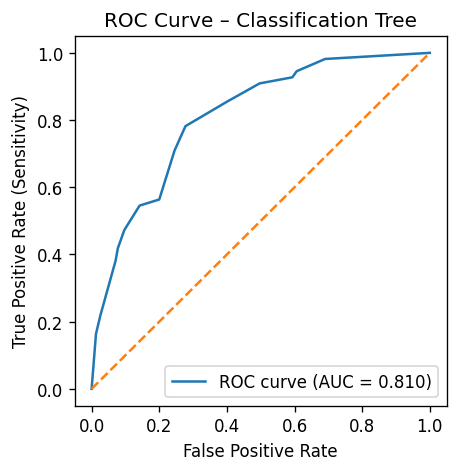

Area Under ROC Curve (AUC): 0.8105


In [11]:
# Predicted probabilities for the positive class (1)
y_proba = clf.predict_proba(X_test)[:, 1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_value = roc_auc_score(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc_value:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve – Classification Tree")
plt.legend(loc="lower right")
plt.show()

print("Area Under ROC Curve (AUC):", round(auc_value, 4))

### 7. Plotting the Classification Tree

We visualize the tree using `plot_tree()` with:
- `filled=True` to color nodes by majority class
- `feature_names` to label splits
- `class_names` to label leaf nodes

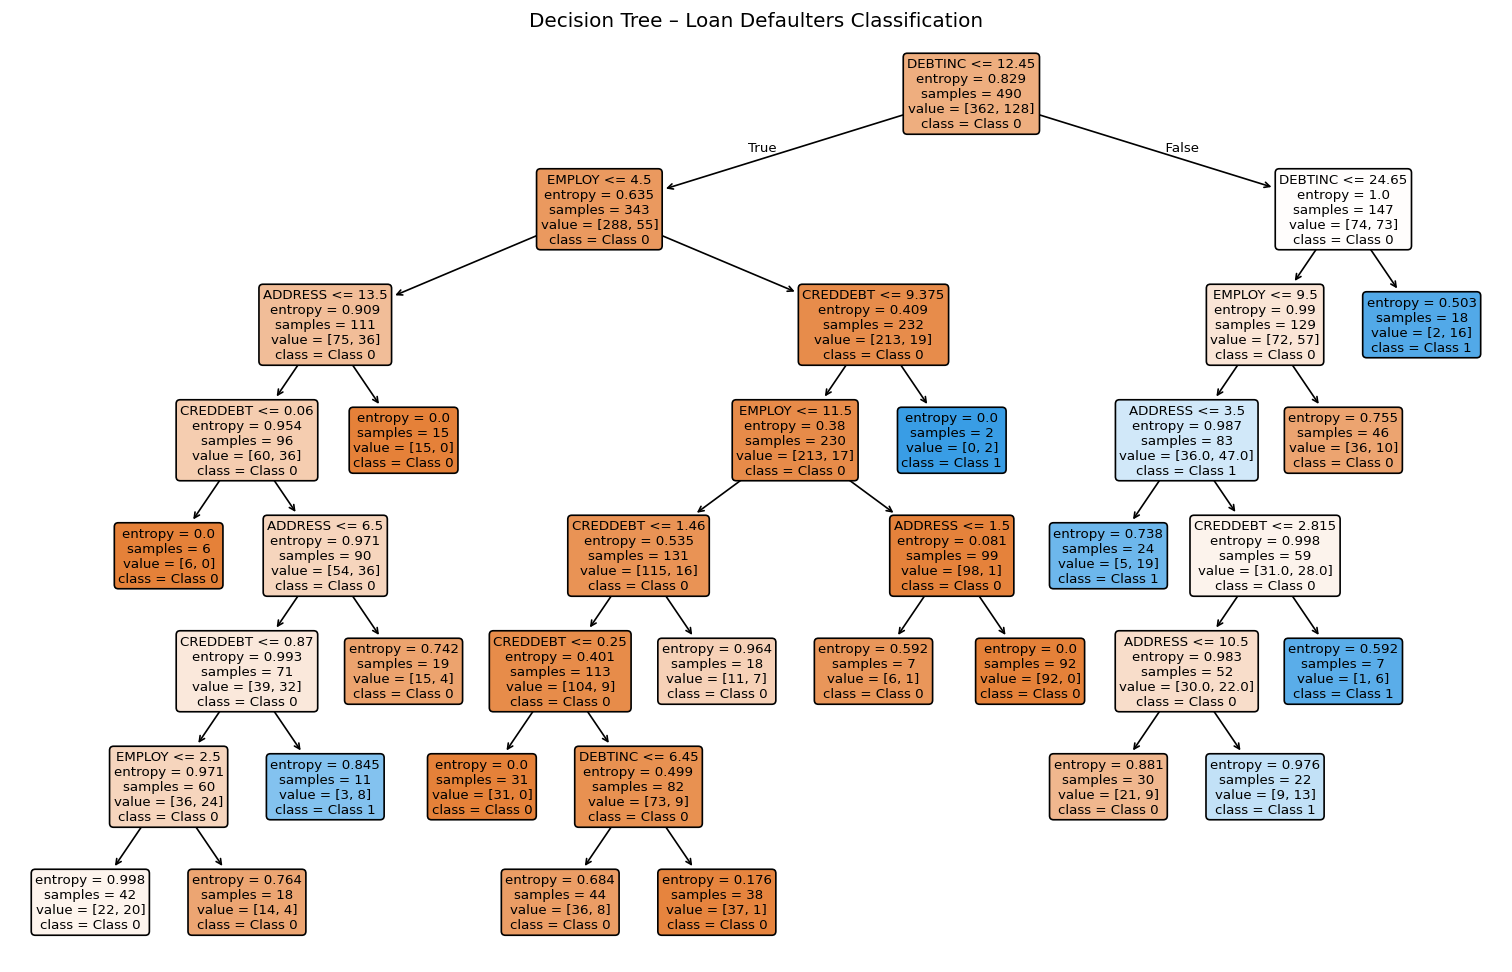

In [12]:
plt.figure(figsize=(16, 10))
plot_tree(
    clf,
    feature_names=X_train.columns,
    class_names=["Class 0", "Class 1"],  # update labels as needed
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.title("Decision Tree – Loan Defaulters Classification")
plt.show()

In [13]:
feature_importances = pd.Series(clf.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)
feature_importances.head(10)

DEBTINC     0.358020
EMPLOY      0.290141
CREDDEBT    0.193787
ADDRESS     0.158053
OTHDEBT     0.000000
AGE_2       0.000000
AGE_3       0.000000
dtype: float64

### Inference :
The model achieves an ROC-AUC of 81%, indicating a reasonably strong ability to distinguish between defaulters and non-defaulters. Debt-to-income ratio is the most influential predictor, followed by years of employment, making them key drivers of default risk.

---
## Part B – Regression Tree (Modeling Motor Insurance Claims)


## Background 

 A motor insurance company routinely collects detailed vehicle and policyholder information at the time of issuing and processing insurance claims. The pricing analytics team periodically analyzes this data to identify risk drivers and determine whether vehicle attributes can be used to model and predict claim severity. The dataset used in this study consists of policyholders from urban locations and includes claims for similar motor insurance products, ensuring consistency in risk exposure and coverage terms.

## Objective

To develop a predictive model that estimates motor insurance claim amount based on specific vehicle-related characteristics recorded during policy registration and claim processing. The insights are expected to support pricing accuracy, risk segmentation, and underwriting decisions.

 
**Data Specifications**

 Sample Size:1,000 motor insurance claim records

Geographical Scope:Urban region customers only

Product Type:Similar motor insurance coverage plan across all records

Observation Type: Individual claim cases

Data Source: Internal structured claim and registration database


## Data Description :

| Columns   | Description                                 | Type     | Measurement |
|-----------|----------------------------------------------|----------|-------------|
| vehage    | Age of the vehicle at the time of claim      | integer  | Years       |
| CC        | Engine capacity                              | numeric  | cc          |
| Length    | Length of the vehicle                        | numeric  | mm          |
| Weight    | Weight of the vehicle                        | numeric  | kg          |
| claimamt  | Claim amount                                 | numeric  | INR         |


### 1. Importing the Data

In [14]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Read the data (update the file name/path as needed)
motor = pd.read_csv("Motor Claims.csv")

# Quick data snapshot
display(motor.head())
print("Shape:", motor.shape)
print("\nData types:\n", motor.dtypes)

,vehage,CC,Length,Weight,claimamt
0,4,1495,4250,1023,72000.0
1,2,1061,3495,875,72000.0
2,2,1405,3675,980,50400.0
3,7,1298,4090,930,39960.0
4,2,1495,4250,1023,106800.0


Shape: (1000, 5)

Data types:
 vehage        int64
CC            int64
Length        int64
Weight        int64
claimamt    float64
dtype: object


In [15]:
# Specify target column
target_col_mc = "claimamt"  

X_mc = motor.drop(columns=[target_col_mc])
y_mc = motor[target_col_mc]

X_train_mc, X_test_mc, y_train_mc, y_test_mc = train_test_split(
    X_mc, y_mc, test_size=0.3, random_state=42
)

print("Training set shape:", X_train_mc.shape)
print("Test set shape:", X_test_mc.shape)

Training set shape: (700, 4)
Test set shape: (300, 4)


### 2. Regression Tree Using Mean Squared Error (MSE)

We build a **Decision Tree Regressor** using:
- `criterion="squared_error"` (default) → minimizes MSE in the nodes.
- `random_state` for reproducibility.

In [16]:
reg_tree = DecisionTreeRegressor(
    criterion="squared_error",  # MSE
    min_samples_split= int(len(X_train)*.10),

    random_state=42
)

reg_tree.fit(X_train_mc, y_train_mc)

print("Tree depth:", reg_tree.get_depth())
print("Number of leaves:", reg_tree.get_n_leaves())

Tree depth: 8
Number of leaves: 28


### 3. Predictions and Regression Metrics

We evaluate the regression tree using:
- **Mean Squared Error (MSE)**  
- **Root Mean Squared Error (RMSE)**  
- **Mean Absolute Error (MAE)**  
- **R-squared (R²)**

In [17]:
# Predictions on TRAIN data
y_pred_train = reg_tree.predict(X_train_mc)

# Train metrics
mse_train = mean_squared_error(y_train_mc, y_pred_train)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train_mc, y_pred_train)
r2_train = r2_score(y_train_mc, y_pred_train)

print("TRAIN MSE :", round(mse_train, 2))
print("TRAIN RMSE:", round(rmse_train, 2))
print("TRAIN MAE :", round(mae_train, 2))
print("TRAIN R^2 :", round(r2_train, 4))

# Predictions on TEST data
y_pred_test = reg_tree.predict(X_test_mc)

# Test metrics
mse_test = mean_squared_error(y_test_mc, y_pred_test)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test_mc, y_pred_test)
r2_test = r2_score(y_test_mc, y_pred_test)

print("\nTEST MSE :", round(mse_test, 2))
print("TEST RMSE:", round(rmse_test, 2))
print("TEST MAE :", round(mae_test, 2))
print("TEST R^2 :", round(r2_test, 4))


TRAIN MSE : 80768220.1
TRAIN RMSE: 8987.11
TRAIN MAE : 6601.08
TRAIN R^2 : 0.8375

TEST MSE : 133318075.28
TEST RMSE: 11546.34
TEST MAE : 8343.29
TEST R^2 : 0.7185


### 4. Plotting the Regression Tree

As with the classification case, we use `plot_tree()` to visualize the regression tree structure.

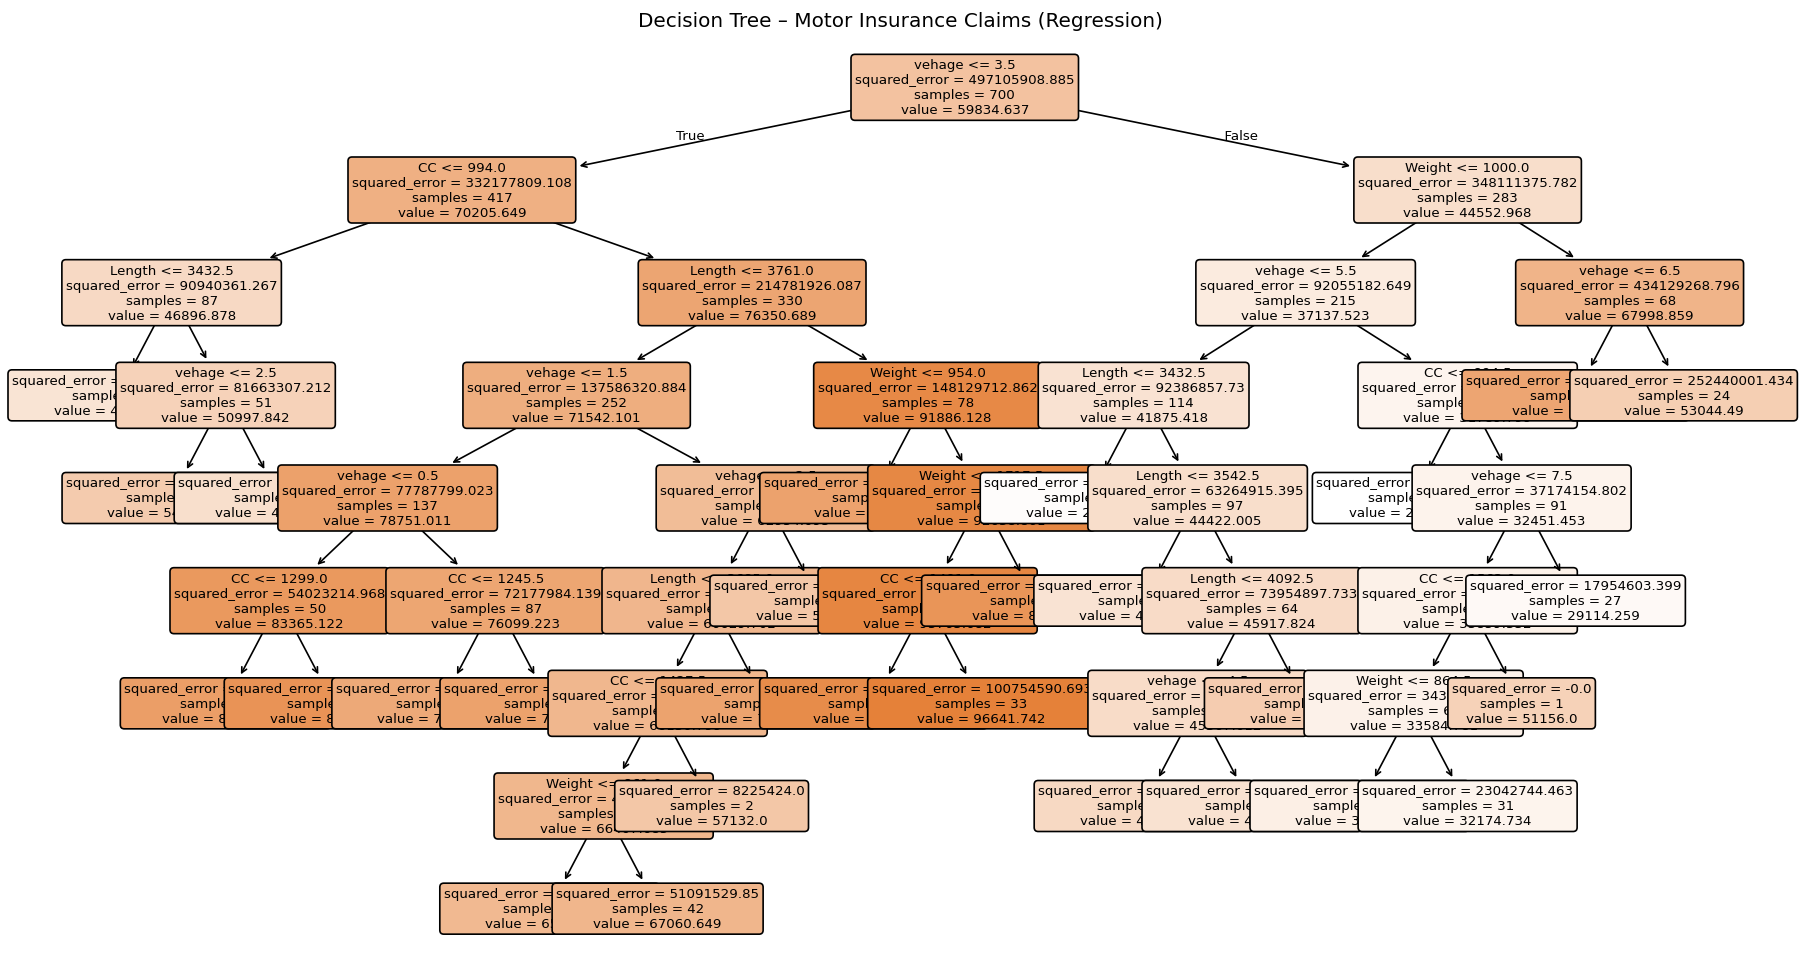

In [19]:
plt.figure(figsize=(18, 10))
plot_tree(
    reg_tree,
    feature_names=X_train_mc.columns,
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.title("Decision Tree – Motor Insurance Claims (Regression)")
plt.show()

### 5. Actual vs Predicted Plot

We compare actual claim amounts with predicted values from the regression tree.

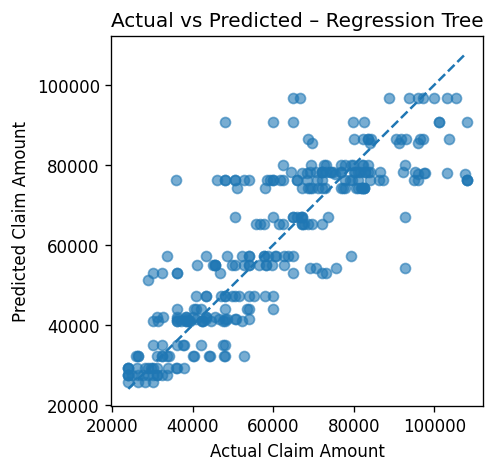

In [20]:
plt.figure()
plt.scatter(y_test_mc, y_pred_mc, alpha=0.6)
max_val = max(y_test_mc.max(), y_pred_mc.max())
min_val = min(y_test_mc.min(), y_pred_mc.min())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Actual Claim Amount")
plt.ylabel("Predicted Claim Amount")
plt.title("Actual vs Predicted – Regression Tree")
plt.show()

In [21]:
feature_importances_mc = pd.Series(reg_tree.feature_importances_, index=X_train_mc.columns)
feature_importances_mc.sort_values(ascending=False).head(10)

vehage    0.502882
CC        0.212883
Weight    0.174280
Length    0.109954
dtype: float64

### Inference :
Decision tree regressor shows good learning performance with a **train R² of 0.84** and a **test R² of 0.72**, indicating that the model generalizes reasonably well with some expected variance. The most influential driver of claim amount is **vehicle age**, followed by engine **CC**, **weight**, and **length**, highlighting that vehicle characteristics strongly impact predicted claim costs.ference :

